# Mall Customer Segmentation Project

### Introduction
This project aims to segment mall customers into meaningful groups based on their demographic and behavioral attributes using a two-step approach. First, K-Means clustering was applied to identify distinct customer segments based on Age, Annual Income, and Spending Score. Then, a Random Forest classifier was trained to predict these customer segments for new or unseen customers. This combined approach enables mall marketing teams to better understand their clientele and develop targeted marketing strategies through effective segmentation and prediction.

In [1]:
# When running KMeans on Windows, we might see a warning about memory issues. This is a known issue with the MKL library. To avoid this warning,set the number of threads:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
# Importing libraries for data manipulation, visualization, preprocessing, and clustering.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

### Data Loading and Preparation 
The Mall Customer Segmentation dataset contains basic customer attributes such as gender, age, annual income, and spending score. This step covers loading the data, inspecting its structure, verifying completeness, and preparing it for analysis by detecting and removing outliers and selecting relevant features. These actions ensure the dataset is clean and ready for effective clustering and modeling.

In [3]:
# Load the Mall_Customers dataset and review its structure.
df = pd.read_csv('Mall_Customers.csv')

In [4]:
# Initial Exploration
print(df.head())
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000       

In [5]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


#### Outlier Detection & Removal
Used the IQR method to detect and remove outliers from key numerical features. This helps ensure that extreme values do not distort clustering results.

In [6]:
# Remove potential outliers using the IQR method.
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

#### Summary
The Mall Customer Segmentation dataset was successfully loaded and inspected, confirming the absence of missing values and appropriate data types across all attributes (Gender, Age, Annual Income, and Spending Score). Outlier detection and removal using the IQR method helped ensure that extreme values would not distort the analysis. By selecting relevant numerical features and preparing a clean dataset, this step establishes a solid foundation for reliable customer segmentation and subsequent modeling.

### Exploratory Data Analysis (EDA)
This section provides a quick overview of the customer distribution and trends to understand the data better before clustering.

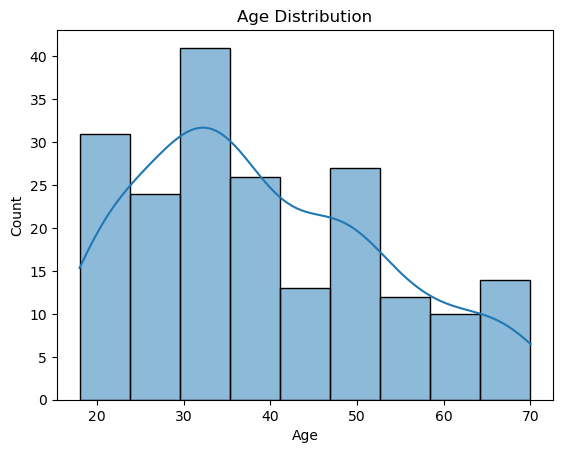

In [7]:
# Visualize Distribution of Age
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

#### Inference
The age distribution reveals a prominent concentration of customers in their late 20s to mid-30s, indicating this as the mall's core demographic. While the customer base spans a wide age range, the frequency generally decreases with age, suggesting a primary appeal to younger adult shoppers.

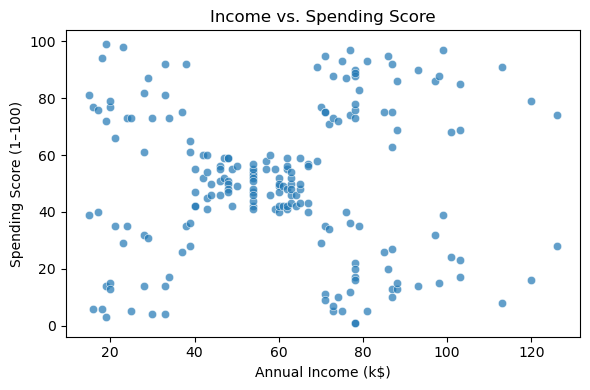

In [8]:
# Visualize Annual Income vs. Spending Score
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', alpha=0.7)
plt.title('Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.tight_layout()
plt.show()

#### Inference
The "Income vs. Spending Score" scatter plot clearly reveals distinct customer groupings, suggesting that these two features are highly influential for segmentation. Five noticeable clusters emerge: customers with high income and high spending, low income and low spending, high income but low spending, low income but high spending, and a central group with moderate income and moderate spending. This visual separation indicates diverse financial capacities and purchasing behaviors among the mall's customer base.

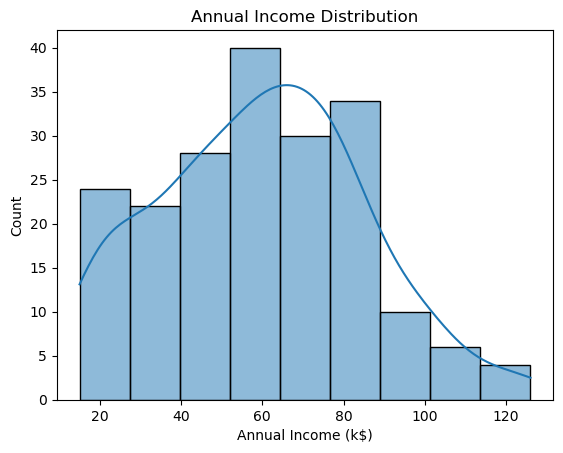

In [9]:
# Annual income distribution
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Annual Income Distribution')
plt.show()

#### Inference
The annual income distribution is centered around $60k–$80k, suggesting most customers are middle-income earners. The relatively balanced spread indicates a stable customer base, with fewer shoppers at very low or very high income levels.

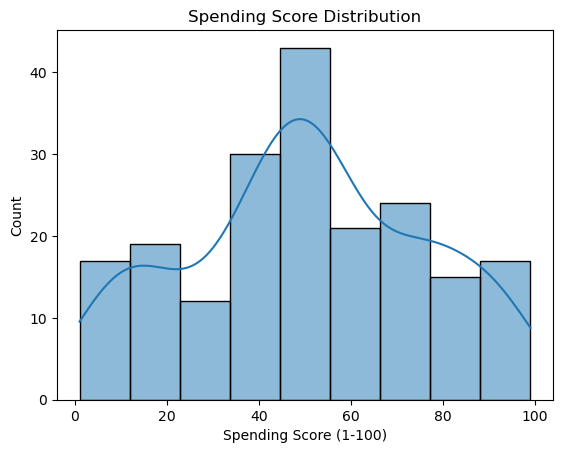

In [10]:
# Spending score distribution
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Spending Score Distribution')
plt.show()

#### Inference
The spending score distribution is fairly spread out, with a noticeable concentration around scores of 40–60, indicating many moderate spenders. Smaller peaks at both low (10–20) and high (70–80) scores suggest the presence of distinct low- and high-spending segments, making spending behavior a key variable for clustering.

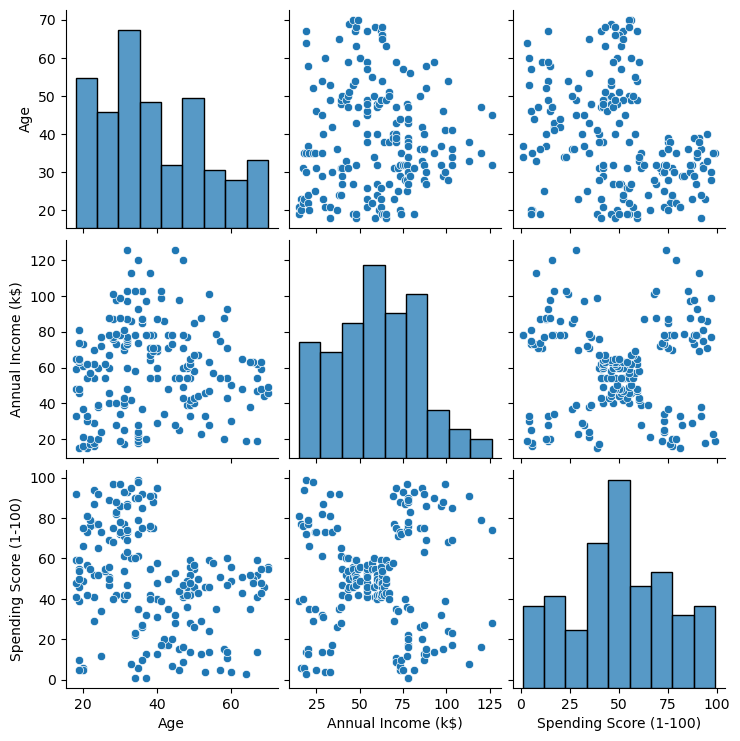

In [11]:
# Pair Plot to observe pairwise relationships between features.
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

#### Inference
The pair plot reveals key patterns among Age, Annual Income, and Spending Score:

- Age vs. Income: No strong linear trend is observed. While younger customers tend to earn less, income levels vary widely for middle-aged individuals, suggesting that age alone doesn't predict income.

- Age vs. Spending Score: Younger customers (20–40) display a wide range of spending behaviors—from low to high scores. In contrast, older customers tend to have more moderate and less varied spending scores.

- Income vs. Spending Score: This relationship shows clear clustering. There are distinct groups such as:

    - Low income, low spending

    - Low income, high spending

    - High income, low spending

    - High income, high spending

    - A moderate group in between

These clusters highlight the value of income and spending score in differentiating customer segments, making them strong features for clustering.

### Clustering & Segmentation
This section applies unsupervised learning to uncover underlying customer segments based on their characteristics. The K-Means clustering algorithm is used to group customers with similar profiles. Before clustering, the selected features—Age, Annual Income, and Spending Score—are standardized to ensure equal contribution. The Elbow Method helps determine the optimal number of clusters. Once clusters are formed, their characteristics are analyzed and visualized to better understand the distinct customer groups present in the dataset.

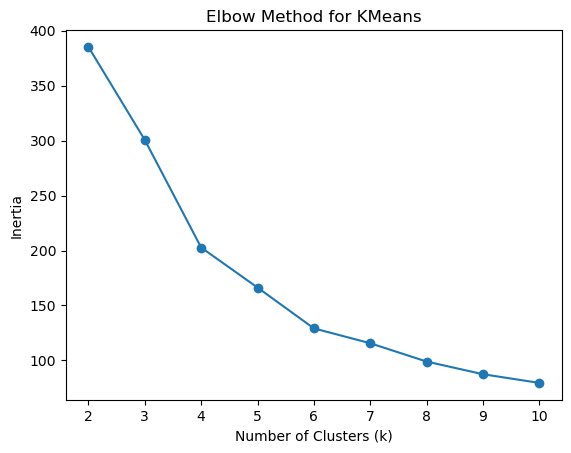

In [12]:
# Scaling features for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

X_scaled = scaler.fit_transform(scaled_features)

# Applying the Elbow Method to find optimal number of clusters
# Used inertia to determine optimal number of clusters.
inertias = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for KMeans')
plt.show()

In [13]:
# Based on the elbow plot, we choose 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the dataframe
df['Cluster'] = clusters

In [14]:
# Describe clusters
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_summary


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,25.2,41.1,62.2
1,32.9,84.8,81.5
2,46.2,26.8,18.4
3,40.1,84.8,19.4
4,55.6,54.4,48.9


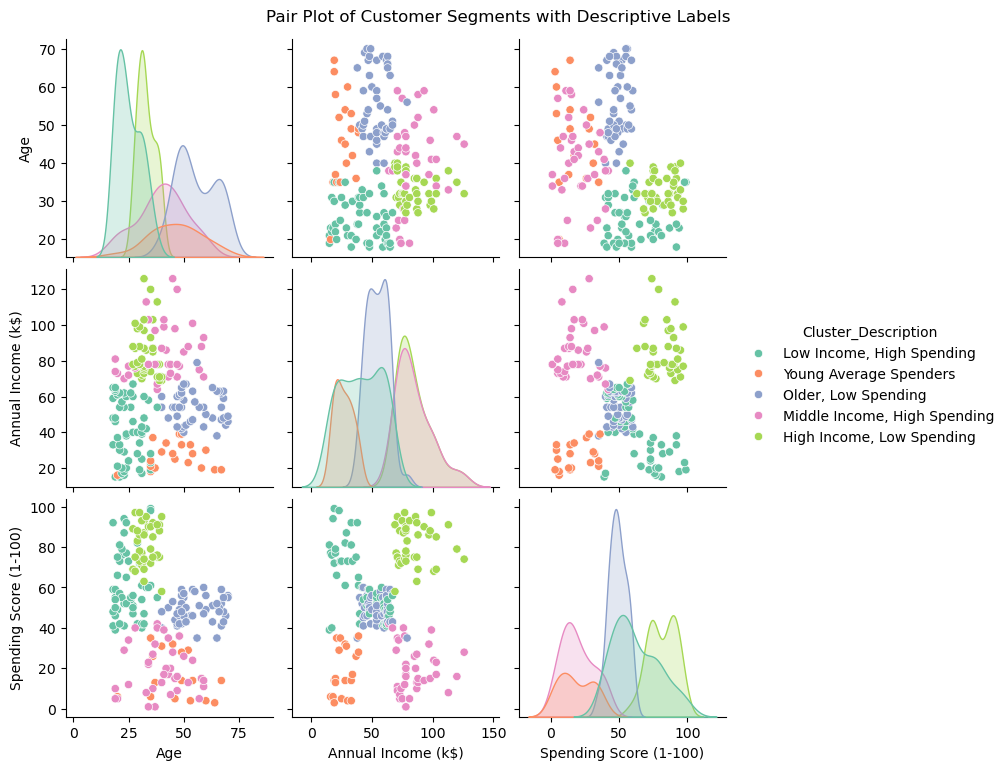

In [15]:
# Label Clusters with Descriptions
cluster_labels = {
    0: 'Low Income, High Spending',
    1: 'High Income, Low Spending',
    2: 'Young Average Spenders',
    3: 'Middle Income, High Spending',
    4: 'Older, Low Spending'
}
df['Cluster_Description'] = df['Cluster'].map(cluster_labels)  # or 'KMeans_Cluster' if that's your column name

# Visualize clusters with descriptive labels in the pairplot
import seaborn as sns
sns.pairplot(
    df,
    hue='Cluster_Description',
    vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    palette='Set2'
)
plt.suptitle('Pair Plot of Customer Segments with Descriptive Labels', y=1.02)
plt.show()


#### Inference 
The pairplot, now color-coded by descriptive cluster labels, enhances interpretability by visually mapping customer segments across Age, Annual Income, and Spending Score.

Based on the legend shown in the visualization, five distinct segments are represented:

- Low Income, High Spending: Younger customers with limited income but high spending behavior—often value-driven or impulsive buyers.

- High Income, Low Spending: Typically middle-aged or older, these customers earn well but spend conservatively—indicating budget-conscious or purpose-driven visits.

- Young Average Spenders: Younger adults with moderate income and spending, likely representing typical casual shoppers.

- Middle Income, High Spending: Customers with mid-level incomes but high spending, possibly frequent or brand-loyal shoppers.

- Older, Low Spending: Older adults with moderate income but low spending, potentially less engaged or infrequent shoppers.

This visualization confirms the effectiveness of the K-Means clustering by showing clear behavioral and demographic separations among the groups. It also validates the descriptive labels used, offering actionable insights for targeted customer engagement strategies.


### Supervised Learning: Predicting Customer Segments
After performing clustering to group similar customers, I trained a supervised machine learning model to predict segment labels for new or unseen customers. This approach is useful when segment labels (from clustering) are already known for a portion of the data, and we want to automate the process for future records.

I chose a Random Forest Classifier for this task because it handles non-linear relationships well, is robust to overfitting, and provides good accuracy with minimal parameter tuning. This helps in classifying customers into meaningful segments, supporting targeted outreach and business decisions.

In [16]:
# Encode the target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Segment_Label'] = le.fit_transform(df['Cluster_Description'])

# Features and target
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Segment_Label']

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)




RandomForestClassifier(random_state=42)

#### Model Evaluation and Visual Assessment
This section presents a comprehensive evaluation of the Random Forest classifier’s performance. It includes quantitative metrics such as accuracy and classification report to measure prediction quality, alongside visual tools like the confusion matrix and feature importance plot to facilitate intuitive understanding and interpretation of the model’s behavior.

In [17]:
# Accuracy and Classification Report
from sklearn.metrics import classification_report, accuracy_score
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0

Classification Report:
                               precision    recall  f1-score   support

   High Income, Low Spending       1.00      1.00      1.00        10
   Low Income, High Spending       1.00      1.00      1.00        10
Middle Income, High Spending       1.00      1.00      1.00         6
         Older, Low Spending       1.00      1.00      1.00        10
      Young Average Spenders       1.00      1.00      1.00         4

                    accuracy                           1.00        40
                   macro avg       1.00      1.00      1.00        40
                weighted avg       1.00      1.00      1.00        40



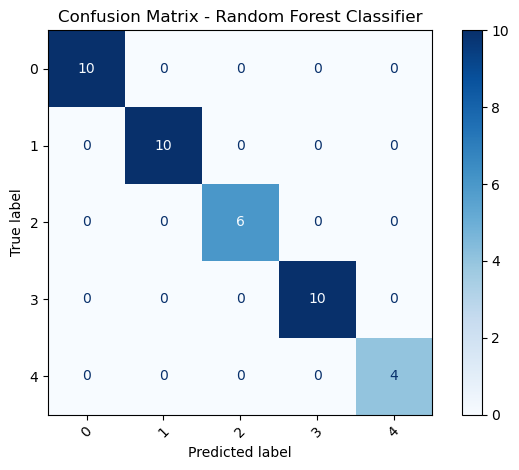

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

# Plot
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


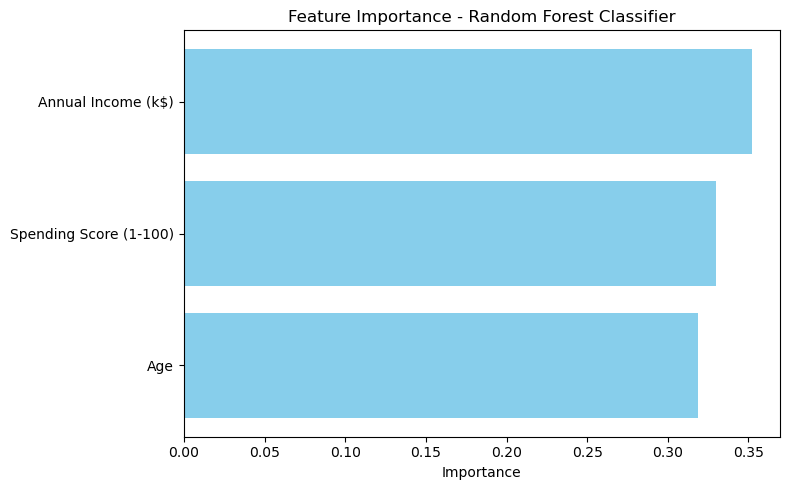

In [19]:
# Feature Importance Plot
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = clf.feature_importances_
features = X.columns

# Create DataFrame for visualization
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Inference
The Random Forest classifier achieved perfect accuracy on the test dataset, correctly classifying every customer segment with precision, recall, and F1-scores of 1.00 across all classes. The confusion matrix confirms this flawless performance, showing no misclassifications and perfect alignment between predicted and actual labels.

Feature importance analysis reveals that Annual Income and Spending Score are the most influential factors in segment differentiation, with Age contributing less but still playing a supportive role. This insight matches earlier visual patterns observed in the data, emphasizing the central role of customers’ financial capacity and spending behavior in defining segments.

While these results are highly encouraging, caution is warranted due to the small test sample size (40 records). Such perfect performance may reflect overfitting and limits the ability to generalize findings. Nevertheless, this project demonstrates a clear methodology for applying supervised learning to customer segmentation. Although conducted on a smaller dataset, this approach can be extended and scaled for real-world applications to create robust, actionable customer targeting strategies.

### Final Project Summary
In this project, I explored customer segmentation using a two-step approach: unsupervised clustering followed by supervised classification. Initially, clustering techniques identified distinct customer groups based on Age, Annual Income, and Spending Score, revealing meaningful patterns that highlight different spending and income behaviors.

Building on this, I trained a Random Forest classifier to predict customer segments, achieving perfect accuracy on the test data. The model’s feature importance analysis confirmed that financial attributes—Annual Income and Spending Score—are the primary drivers of customer segmentation, while Age provides additional context.

Despite the encouraging results, the relatively small dataset limits the ability to fully generalize these findings. This project demonstrates how combining exploratory and predictive modeling can enhance customer segmentation, and how this approach can be extended to larger, real-world datasets. It offers practical insights for businesses aiming to tailor marketing strategies and improve customer targeting through data-driven segmentation.

